# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [1]:
!git clone https://github.com/siwenliao/linear_models
%cd linear_models/lab

Cloning into 'linear_models'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 92 (delta 26), reused 12 (delta 12), pack-reused 56 (from 2)
Receiving objects: 100% (92/92), 4.98 MiB | 13.70 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/linear_models/lab


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Shape: (16814, 19) 

Types: sale_date                      object
sale_price                      int64
house_square_feet               int64
attic_finished_square_feet      int64
basement_square_feet            int64
attached_garage_square_feet     int64
detached_garage_square_feet     int64
fireplaces                      int64
hvac_description               object
exterior                       object
interior                       object
stories                         int64
roof_cover                     object
year_built                      int64
bedrooms                        int64
bathrooms                       int64
waterfront_type                object
view_quality                   object
utility_sewer                  object
dtype: object 

Columns: Index(['sale_date', 'sale_price', 'house_square_feet',
       'attic_finished_square_feet', 'basement_square_feet',
       'attached_garage_square_feet', 'detached_garage_square_feet',
       'fireplaces', 'hvac_description',

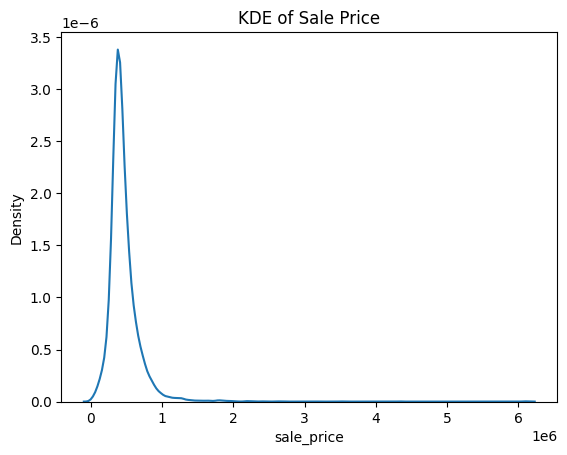

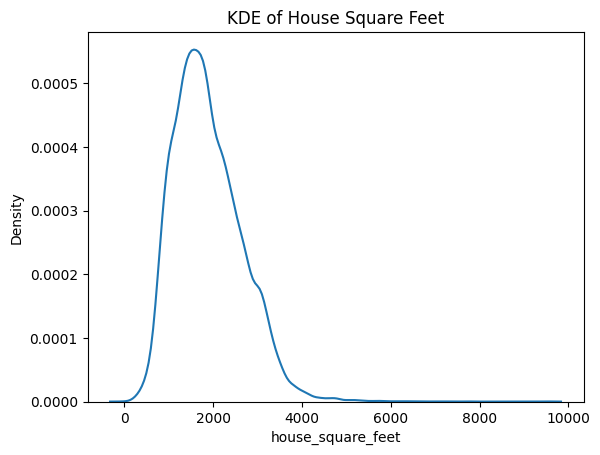

<Figure size 640x480 with 0 Axes>

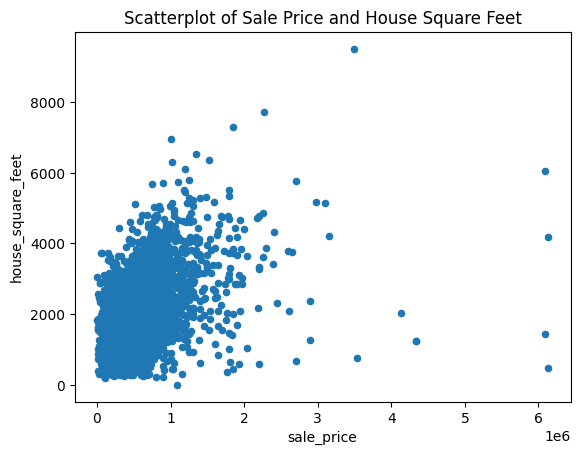

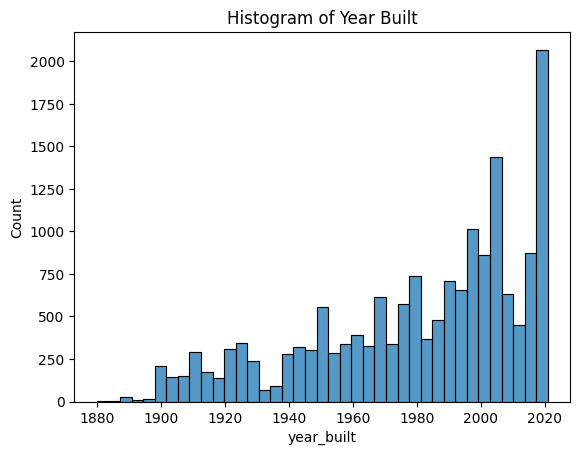

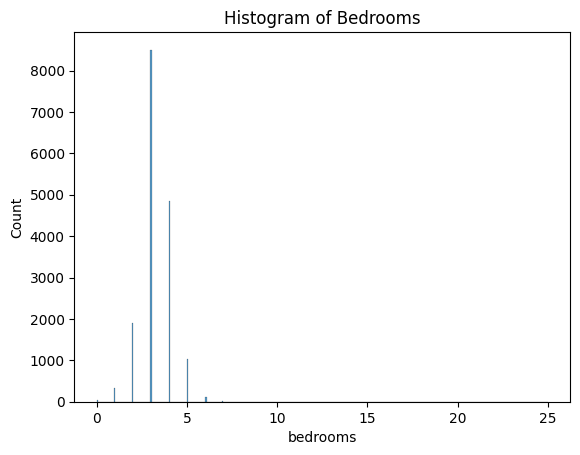

In [45]:
# 1: Clean the data and perform EDA/visualizations

df = pd.read_csv('./data/pierce_county_house_sales.csv')

print('Shape:', df.shape, '\n')
print('Types:', df.dtypes, '\n')
print('Columns:', df.columns, '\n')
print(df.describe(), '\n')
print(df.isnull().sum().sort_values(ascending=False), '\n')

df['sale_date'] = pd.to_datetime(df['sale_date'])
df['waterfront_type'] = df['waterfront_type'].fillna('None')
df['view_quality'] = df['view_quality'].fillna('None')
df['roof_cover'] = df['roof_cover'].fillna('Unknown')
df['hvac_description'] = df['hvac_description'].fillna('Unknown')
df['interior'] = df['interior'].fillna('Unknown')
df['exterior'] = df['exterior'].fillna('Unknown')

print(df['hvac_description'].unique(), '\n')
print(df['interior'].unique(), '\n')
print(df['exterior'].unique(), '\n')
print(df['roof_cover'].unique(), '\n')
print(df['utility_sewer'].unique(), '\n')

df['hvac_description']=df['hvac_description'].replace('Floor Wall Furnace', 'Floor/Wall Furnace')
df['hvac_description']=df['hvac_description'].replace('Electric', 'Electric Baseboard')

df['exterior']=df['exterior'].replace('Frame Rustic Log', 'Log')

df['utility_sewer']=df['utility_sewer'].replace('SEWER/SEPTIC NO PERC', 'SEWER/SEPTIC NO')
df['utility_sewer']=df['utility_sewer'].replace('SEWER AVAILABLE', 'SEWER/SEPTIC AVAIL')

plt.figure()
fig = sns.kdeplot(df['sale_price'])
fig.set(title='KDE of Sale Price')
plt.show()

plt.figure()
fig1 = sns.kdeplot(df['house_square_feet'])
fig1.set(title='KDE of House Square Feet')
plt.show()

plt.figure()
df.plot.scatter(x='sale_price',y='house_square_feet')
plt.title('Scatterplot of Sale Price and House Square Feet')
plt.show()

plt.figure()
fig1 = sns.histplot(df['year_built'])
fig1.set(title='Histogram of Year Built')
plt.show()

plt.figure()
fig1 = sns.histplot(df['bedrooms'])
fig1.set(title='Histogram of Bedrooms')
plt.show()


In [60]:
# 2: Transform variables for use in regression analysis

df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month

num_var = ['house_square_feet', 'attic_finished_square_feet', 'basement_square_feet',
           'attached_garage_square_feet', 'detached_garage_square_feet', 'fireplaces',
           'stories', 'year_built', 'bedrooms', 'bathrooms', 'sale_year', 'sale_month']

cat_var = ['waterfront_type', 'view_quality', 'roof_cover', 'hvac_description',
           'interior', 'exterior', 'utility_sewer']

def minmax(z):
    z = (z-min(z))/(max(z)-min(z))
    return z

X_n = df.loc[:,num_var]
X_n = X_n.apply(minmax,axis=1)

dummies = pd.DataFrame([])
for var in cat_var:
    new_dummies = pd.get_dummies( df.loc[:,var], drop_first=True, dtype=int)
    dummies = pd.concat([dummies, new_dummies], axis=1, ignore_index=True)

X = pd.concat([X_n,dummies],axis=1)
X.columns = X.columns.astype(str)
y = df['sale_price']

In [62]:
# 3: Implement an 80/20 train-test split. Put the test data aside.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=.2,
                                                    random_state=65)

In [67]:
# 4: Simple linear models that include no transformations or interactions

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    return train_rmse, test_rmse, train_r2, test_r2

model1 = LinearRegression().fit(X_train[num_var], y_train)
m1 = evaluate_model(model1, X_train[num_var], X_test[num_var], y_train, y_test)

dummy_cols = dummies.columns.astype(str).tolist()
model2 = LinearRegression().fit(X_train[dummy_cols], y_train)
m2 = evaluate_model(model2, X_train[dummy_cols], X_test[dummy_cols], y_train, y_test)

model3 = LinearRegression().fit(X_train, y_train)
m3 = evaluate_model(model3, X_train, X_test, y_train, y_test)

results = pd.DataFrame({
    'Model': ['Model1', 'Model2', 'Model3'],
    'Train RMSE': [m1[0], m2[0], m3[0]],
    'Test RMSE': [m1[1], m2[1], m3[1]],
    'Train R2': [m1[2], m2[2], m3[2]],
    'Test R2': [m1[3], m2[3], m3[3]]
})

print(results)

    Model     Train RMSE      Test RMSE  Train R2   Test R2
0  Model1  190364.670932  172249.075967  0.362214  0.422497
1  Model2  193308.880267  183814.149596  0.342333  0.342344
2  Model3  163777.060045  153127.494931  0.527928  0.543599


Model 3 does the best because it has the lowest Test RMSE value and the highest Test R2 value. Model 3 is the linear model with all variables included.

In [ ]:
# 5: Partial Correlation Plots for Numeric Variables

